In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf

INFO:2025-11-20 11:43:15,671:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [4]:
from simulators.benchmarks import DDM

In [5]:
num_obs = 500
epochs = 500
batch_size = 32
batches_per_epoch = 500
summary_dim = 64
seed_dim = 128
# num_train = 10000
# num_val = 100

### Workflow

In [6]:
simulator = DDM()

In [7]:
samples = simulator.sample(batch_size=batch_size)

In [8]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .drop(["decay"])
    .concatenate(["v", "a", "tau", "s_v", "s_tau"], axis=-1, into="inference_variables")
    .concatenate(["rts", "choices"], into="summary_variables")
)

In [9]:
summary_network = bf.networks.SetTransformer(summary_dim=summary_dim, seed_dim=seed_dim)
inference_network = bf.networks.FlowMatching()

In [10]:
workflow = bf.BasicWorkflow(
    inference_network=inference_network,
    summary_network=summary_network,
    simulator=simulator,
    adapter=adapter,
    checkpoint_filepath=f"../checkpoints/ddm_online_{epochs}_{summary_dim}_{seed_dim}.ckpt",
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [12]:
validation_data = workflow.simulate(500)

In [14]:
history = workflow.fit_online(
    epochs=epochs,
    batch_size=batch_size,
    num_batches_per_epoch=batches_per_epoch,
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - loss: 2.3687 - val_loss: 1.1865
Epoch 2/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 1.2441 - val_loss: 0.9919
Epoch 3/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - loss: 1.0101 - val_loss: 0.9283
Epoch 4/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - loss: 0.8663 - val_loss: 0.6181
Epoch 5/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - loss: 0.7411 - val_loss: 0.5554
Epoch 6/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 97ms/step - loss: 0.7006 - val_loss: 0.5855
Epoch 7/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 112ms/step - loss: 0.6665 - val_loss: 0.5827
Epoch 8/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 146ms/step - loss: 0.6465 - val_loss: 0.5321
Epoch 9/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 85s 170ms/step - loss: 0.6395 - val_loss: 0.5830
Epoch 10/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 88s 176ms/step - loss: 0.6031 - val_loss: 0.5201
Epoch 11/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - loss: 0.5903 - val_loss: 0.5063
Epoch 12/500
5

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../checkpoints/ddm_online_500_64_128.ckpt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


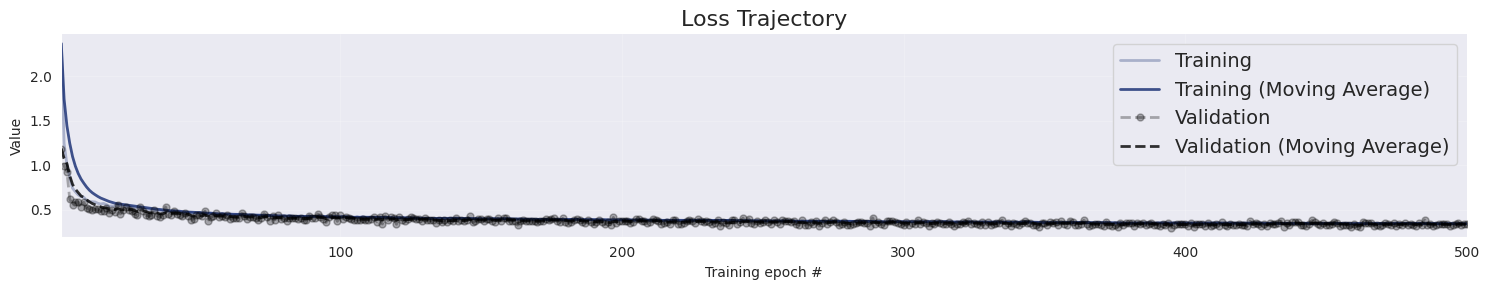

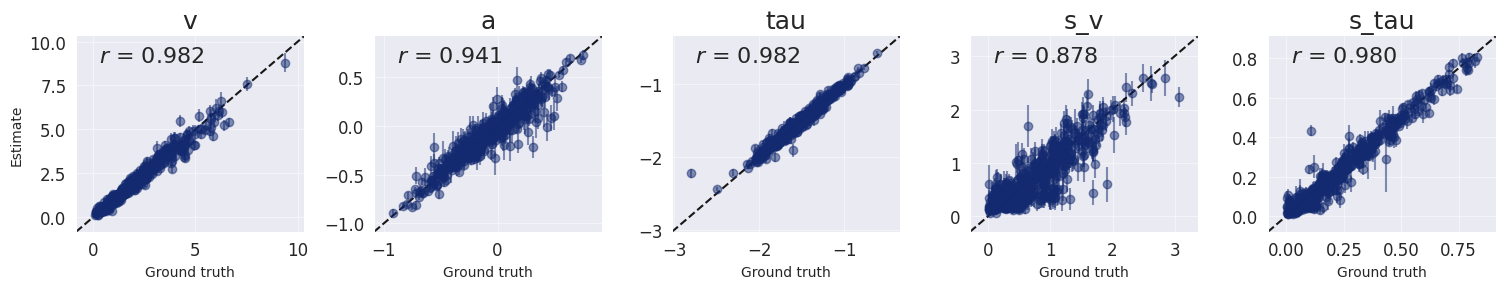

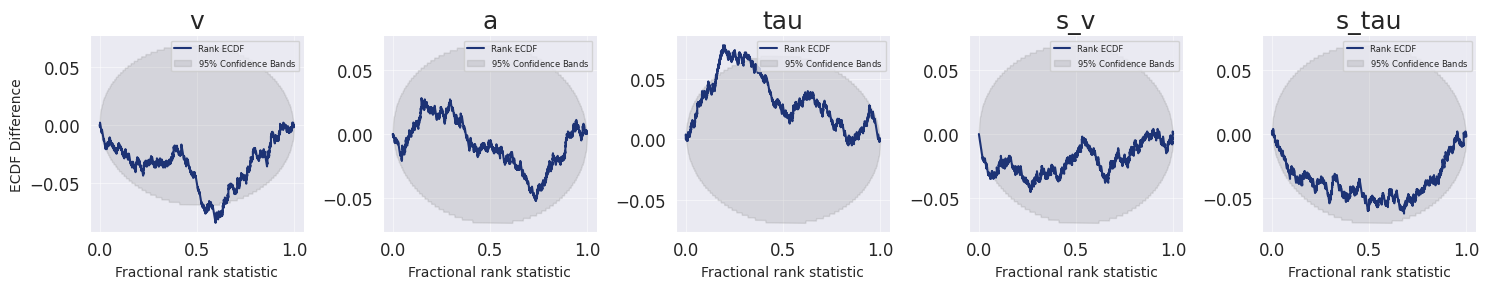

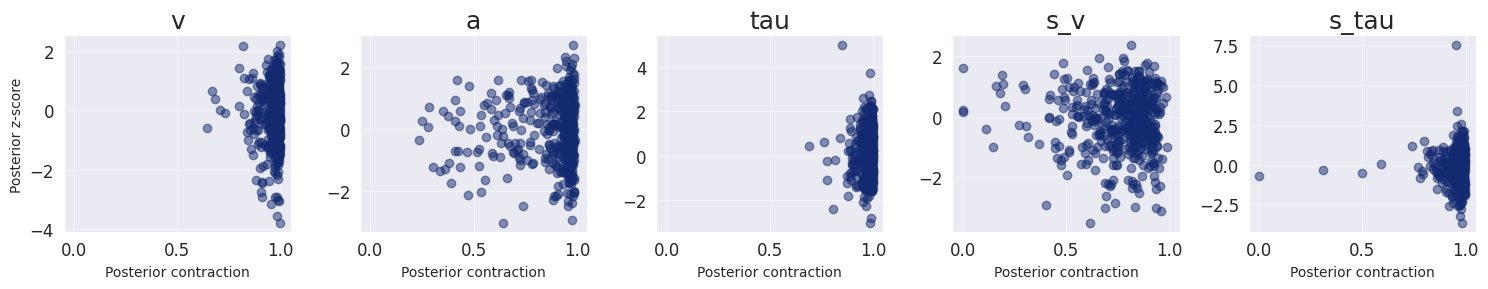

In [15]:
fig = workflow.plot_default_diagnostics(
    test_data=validation_data,
    variable_names=["v", "a", "tau", "s_v", "s_tau"],
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    recovery_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    calibration_ecdf_kwargs={"figsize": (15, 3), "legend_fontsize": 6, "difference": True, "label_fontsize": 10},
    z_score_contraction_kwargs={"figsize": (15, 3), "label_fontsize": 10}
)

In [17]:
metrics = workflow.compute_default_diagnostics(test_data=validation_data)

In [18]:
metrics

,v,a,tau,s_v,s_tau
NRMSE,0.041433,0.083111,0.033145,0.125102,0.068603
Posterior Contraction,0.977826,0.951804,0.984105,0.813170,0.975074
Calibration Error,0.013579,0.016895,0.033579,0.015474,0.004632
